# Gaussian Mixture Model + Interpretation

> **ENSIA · OULAD Student Clustering · Spring 2025–2026**

This notebook is the GMM baseline for the project. It follows the paper's unsupervised spirit by training only on behavioral features, then mapping mixture components to student archetypes after the fact.

The paper by Peach et al. uses DTW + RMST + Markov Stability on temporal click sequences. Here we adapt that idea to this repository's engineered features with Gaussian Mixture Models, BIC-based component selection, and post-hoc cluster profiling against `final_result`.


## Goal

- Fit a Gaussian Mixture Model on the scaled feature matrix only.
- Select the number of components with information criteria and clustering scores.
- Save the trained model to `models/gmm.pkl`.
- Interpret each component as a student type using only post-hoc summaries.
- Check whether low-performing students concentrate in a particular behavioral cluster.


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FEATURE_COLS, build_feature_matrix, scale_features

sns.set_theme(style='whitegrid', context='talk')

In [3]:
NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'figures'

for directory in [MODELS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

master_raw_path = PROCESSED_DIR / 'master_raw.csv'
student_assessment_path = RAW_DIR / 'studentAssessment.csv'
assessments_path = RAW_DIR / 'assessments.csv'

features_df = build_feature_matrix(master_raw_path, student_assessment_path, assessments_path)
X = features_df[FEATURE_COLS].copy()
X_scaled, scaler = scale_features(X.values, MODELS_DIR, save_name='scaler.pkl')

print(f'Rows: {len(features_df):,}')
print(f'Features: {len(FEATURE_COLS)}')
features_df.head()

Rows: 32,593
Features: 17


,id_student,code_module,code_presentation,final_result,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,...,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
0,11391,AAA,2013J,Pass,6.840547,0.149254,0.488223,0.139186,0.016060,-1.546179,...,0.206638,0.0,82.4,0.244966,0.8,0.0,-1.800000,0,159.0,3
1,28400,AAA,2013J,Pass,7.269617,0.298507,0.374216,0.295470,0.000000,-1.046895,...,0.290592,0.0,65.4,0.187410,-2.4,0.0,0.000000,0,53.0,3
2,30268,AAA,2013J,Withdrawn,5.641907,0.044776,0.637011,0.000000,0.000000,0.000000,...,0.448399,0.0,0.0,0.500000,0.0,0.0,-10.852925,0,92.0,2
3,31604,AAA,2013J,Pass,7.677400,0.458955,0.363299,0.234940,0.002317,-1.200212,...,0.293791,0.0,76.3,0.126710,2.3,0.0,-2.000000,0,52.0,2
4,32885,AAA,2013J,Pass,6.942157,0.261194,0.320116,0.191489,0.024178,-0.879107,...,0.187621,0.0,55.0,0.046483,1.7,0.0,11.400000,0,176.0,1


,n_components,bic,aic,silhouette,calinski_harabasz,davies_bouldin
0,2,794439.661573,791578.039762,0.238648,8948.973605,1.796820
1,3,277643.543670,273346.915026,0.163914,6421.281559,2.217901
2,4,45710.547798,39978.912322,0.189041,5660.794818,2.849862
3,5,-208984.021351,-216150.663660,0.196092,4792.879418,2.402929
4,6,-235519.634977,-244121.284117,0.101707,4091.351211,2.791860
5,7,-333355.151016,-343391.806989,0.118847,3679.058055,2.757986
6,8,-434104.182474,-445575.845279,0.074189,3031.960788,3.124838


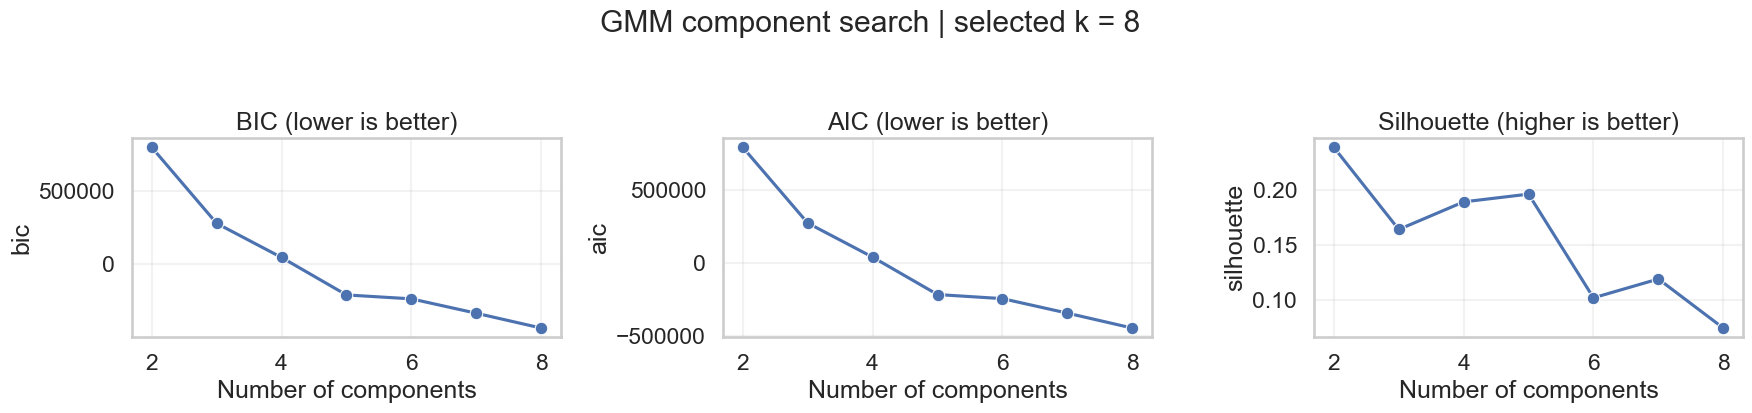

In [4]:
candidate_components = range(2, 9)
search_rows = []

for n_components in candidate_components:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=42,
        n_init=10,
        reg_covar=1e-6,
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    unique_labels = np.unique(labels)

    if 1 < len(unique_labels) < len(labels):
        silhouette = silhouette_score(X_scaled, labels)
        calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
        davies_bouldin = davies_bouldin_score(X_scaled, labels)
    else:
        silhouette = np.nan
        calinski_harabasz = np.nan
        davies_bouldin = np.nan

    search_rows.append({
        'n_components': n_components,
        'bic': gmm.bic(X_scaled),
        'aic': gmm.aic(X_scaled),
        'silhouette': silhouette,
        'calinski_harabasz': calinski_harabasz,
        'davies_bouldin': davies_bouldin,
    })

gmm_search = pd.DataFrame(search_rows).sort_values('n_components').reset_index(drop=True)
best_n_components = int(gmm_search.sort_values(['bic', 'aic'], ascending=[True, True]).iloc[0]['n_components'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.lineplot(data=gmm_search, x='n_components', y='bic', marker='o', ax=axes[0])
axes[0].set_title('BIC (lower is better)')
sns.lineplot(data=gmm_search, x='n_components', y='aic', marker='o', ax=axes[1])
axes[1].set_title('AIC (lower is better)')
sns.lineplot(data=gmm_search, x='n_components', y='silhouette', marker='o', ax=axes[2])
axes[2].set_title('Silhouette (higher is better)')
for ax in axes:
    ax.set_xlabel('Number of components')
    ax.grid(True, alpha=0.25)
fig.suptitle(f'GMM component search | selected k = {best_n_components}', y=1.05)
plt.tight_layout()
gmm_search

In [5]:
gmm = GaussianMixture(
    n_components=best_n_components,
    covariance_type='full',
    random_state=42,
    n_init=10,
    reg_covar=1e-6,
)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probabilities = gmm.predict_proba(X_scaled)
gmm_max_prob = gmm_probabilities.max(axis=1)

features_df = features_df.assign(
    gmm_cluster=gmm_labels,
    gmm_max_prob=gmm_max_prob,
)

joblib.dump(gmm, MODELS_DIR / 'gmm.pkl')
features_df.to_csv(PROCESSED_DIR / 'master_with_gmm_clusters.csv', index=False)

print(f'Saved model to: {MODELS_DIR / "gmm.pkl"}')
print(f'Saved clustered table to: {PROCESSED_DIR / "master_with_gmm_clusters.csv"}')
print(f'Cluster labels: {np.unique(gmm_labels)}')

Saved model to: F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\models\gmm.pkl
Saved clustered table to: F:\summer\S6\machine learning\student behaviour project\actual\Student-Learning-Behavior-Clustering-Profiling\data\processed\master_with_gmm_clusters.csv
Cluster labels: [0 1 2 3 4 5 6 7]


In [6]:
cluster_summary = (
    features_df.groupby('gmm_cluster', observed=True)
    .agg(
        size=('id_student', 'count'),
        avg_weighted_score=('weighted_avg_score', 'mean'),
        avg_missing_submission_rate=('missing_submission_rate', 'mean'),
        avg_early_click_ratio=('early_click_ratio', 'mean'),
        avg_late_click_ratio=('late_click_ratio', 'mean'),
        avg_click_in_final_week_ratio=('click_in_final_week_ratio', 'mean'),
        avg_active_day_rate=('active_day_rate', 'mean'),
        avg_total_clicks_log=('total_clicks_log', 'mean'),
        avg_gmm_max_prob=('gmm_max_prob', 'mean'),
        dominant_final_result=('final_result', lambda s: s.value_counts().idxmax()),
    )
    .sort_values('size', ascending=False)
)

behavior_labels = {}
remaining_clusters = set(cluster_summary.index.tolist())

if remaining_clusters:
    struggling_cluster = cluster_summary['avg_weighted_score'].idxmin()
    behavior_labels[struggling_cluster] = 'Struggling / At-risk'
    remaining_clusters.remove(struggling_cluster)

if remaining_clusters:
    high_performer_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_weighted_score'].idxmax()
    behavior_labels[high_performer_cluster] = 'High Performer'
    remaining_clusters.remove(high_performer_cluster)

if remaining_clusters:
    last_minute_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_late_click_ratio'].idxmax()
    behavior_labels[last_minute_cluster] = 'Last-minute Learner'
    remaining_clusters.remove(last_minute_cluster)

if remaining_clusters:
    consistent_cluster = cluster_summary.loc[list(remaining_clusters), 'avg_active_day_rate'].idxmax()
    behavior_labels[consistent_cluster] = 'Consistent Learner'
    remaining_clusters.remove(consistent_cluster)

for cluster_id in remaining_clusters:
    behavior_labels[cluster_id] = 'Secondary / Mixed Pattern'

features_df['student_type'] = features_df['gmm_cluster'].map(behavior_labels)
cluster_summary['student_type'] = cluster_summary.index.map(behavior_labels)
cluster_summary['share_of_students'] = cluster_summary['size'] / len(features_df)

cluster_summary

,size,avg_weighted_score,avg_missing_submission_rate,avg_early_click_ratio,avg_late_click_ratio,avg_click_in_final_week_ratio,avg_active_day_rate,avg_total_clicks_log,avg_gmm_max_prob,dominant_final_result,student_type,share_of_students
gmm_cluster,,,,,,,,,,,,
4,11295,69.514540,0.000000,0.351695,0.304953,2.122341e-02,0.383791,7.368138,0.988174,Pass,Consistent Learner,0.346547
2,6025,56.998909,0.739662,0.805126,0.000001,0.000000e+00,0.091594,5.612333,0.989754,Withdrawn,Secondary / Mixed Pattern,0.184856
0,3853,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000846,0.278427,0.999888,Withdrawn,Struggling / At-risk,0.118216
3,3034,0.000000,0.000000,0.686981,0.000000,0.000000e+00,0.025860,3.941667,0.999999,Withdrawn,Secondary / Mixed Pattern,0.093087
5,2803,71.023511,0.189365,0.424502,0.233537,2.071548e-02,0.293001,6.867036,0.959008,Pass,High Performer,0.086000
6,2101,61.229900,0.290664,0.528585,0.116573,0.000000e+00,0.160025,6.044070,0.949846,Fail,Secondary / Mixed Pattern,0.064462
1,1823,65.435700,0.108921,0.322868,0.352026,8.549183e-02,0.343140,7.286946,0.990515,Pass,Last-minute Learner,0.055932
7,1659,36.262696,0.310727,0.381216,0.285969,7.743740e-08,0.188913,6.438825,0.980290,Fail,Secondary / Mixed Pattern,0.050901


,gmm_cluster,student_type,final_result
0,4,Consistent Learner,Pass
1,4,Consistent Learner,Pass
2,3,Secondary / Mixed Pattern,Withdrawn
3,4,Consistent Learner,Pass
4,4,Consistent Learner,Pass


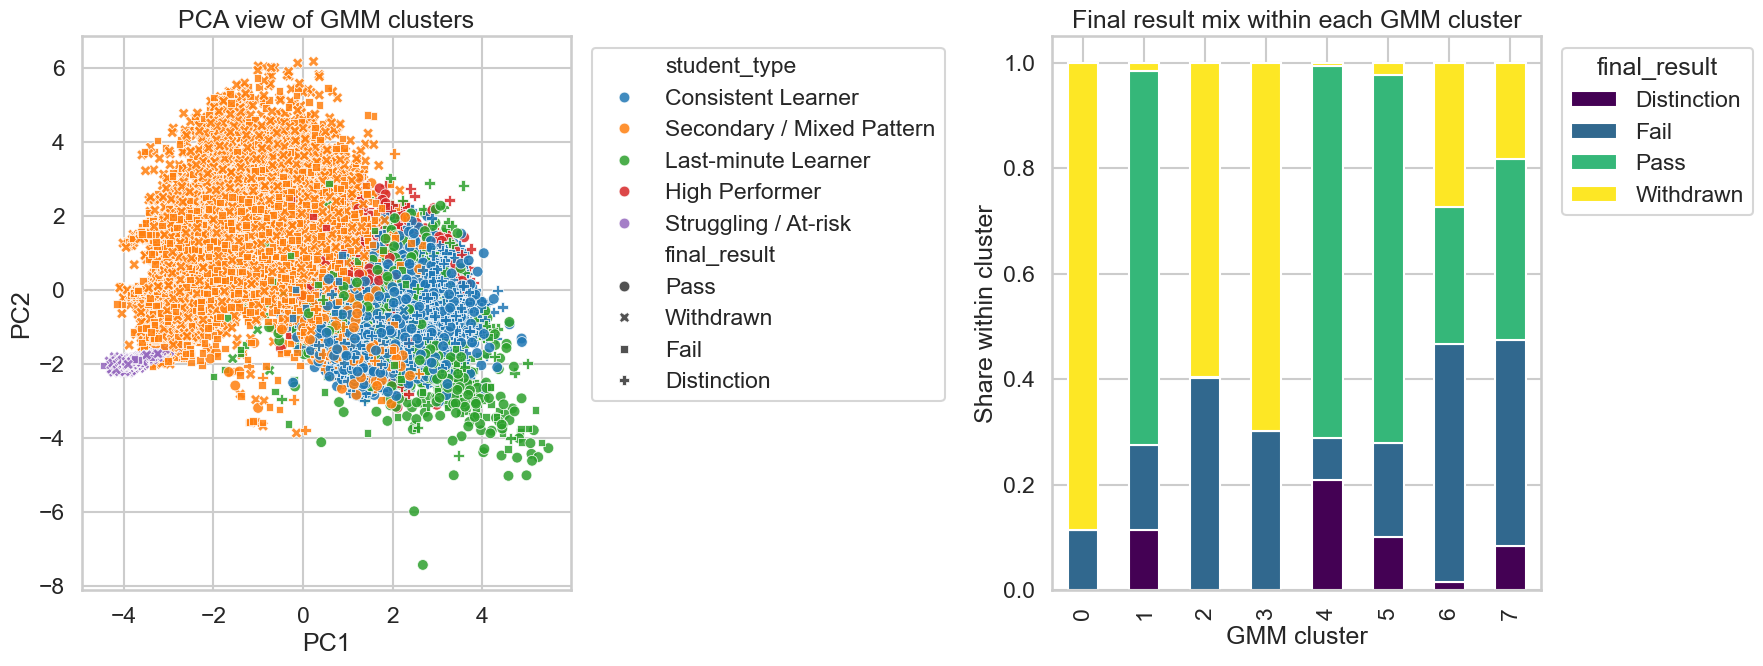

In [7]:
cluster_result_share = pd.crosstab(
    features_df['gmm_cluster'],
    features_df['final_result'],
    normalize='index',
)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
plot_df = features_df.copy()
plot_df['PC1'] = pca_coords[:, 0]
plot_df['PC2'] = pca_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='student_type',
    style='final_result',
    palette='tab10',
    alpha=0.85,
    s=60,
    ax=axes[0],
)
axes[0].set_title('PCA view of GMM clusters')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

cluster_result_share.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Final result mix within each GMM cluster')
axes[1].set_xlabel('GMM cluster')
axes[1].set_ylabel('Share within cluster')
axes[1].legend(title='final_result', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plot_df[['gmm_cluster', 'student_type', 'final_result']].head()

## Interpretation Notes

If the mapping behaves as expected, the cluster with the lowest weighted score and highest missing-submission rate should resemble an at-risk / struggling profile. The cluster with high early-click ratio, higher active-day rate, and better scores should align with a high-performing or consistent learner profile.

That is the right way to read this notebook: GMM does not use student labels during training, but the cluster summaries tell us whether the discovered mixture components line up with the student types we care about.

If the result is not clean enough, the next lever is not to inject labels into training. Instead, refine the feature set, test a different `n_components`, or compare `covariance_type` settings (`full`, `diag`, `tied`, `spherical`).
